# Route 208 BEB result visualisation

This notebook visualises the output from the BEB route simulation.

It focuses on three questions:

1. How does passenger loading vary across trips during the day?
2. How does energy consumption vary by stop-to-stop segment and by time of day?
3. Are the results physically reasonable and useful for further BEB charging analysis?

**Input expected:** a route-level result CSV generated by `gtfs_to_segments.py`


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Set file paths



In [2]:
ROUTE_RESULTS_PATH = Path("../data/processed/route_208_trips.csv")

# Optional fallback
if not ROUTE_RESULTS_PATH.exists():
    fallback_path = Path("route_208_trips.csv")
    if fallback_path.exists():
        ROUTE_RESULTS_PATH = fallback_path

# Folder for saved figures.
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True

print("Using route result file:", ROUTE_RESULTS_PATH)
print("Figure output folder:", FIGURE_DIR)

Using route result file: ..\data\processed\route_208_trips.csv
Figure output folder: ..\reports\figures


## 2. Load and inspect the result file

In [3]:
df = pd.read_csv(ROUTE_RESULTS_PATH)

print("Rows:", len(df))
print("Columns:", list(df.columns))

display(df.head())

Rows: 7622
Columns: ['route_short_name', 'route_long_name', 'route_id', 'direction_id', 'trip_id', 'trip_start_time', 'segment', 'length_m', 'grade_%', 'passengers', 'energy_kWh', 'kWh_per_km', 'cum_dist_km', 'SoC_start_%', 'SoC_end_%']


,route_short_name,route_long_name,route_id,direction_id,trip_id,trip_start_time,segment,length_m,grade_%,passengers,energy_kWh,kWh_per_km,cum_dist_km,SoC_start_%,SoC_end_%
0,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,0,5695_40633,06:30:00,0,215.9,-0.46,0,0.183,0.846,0.216,100.00,99.96
1,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,0,5695_40633,06:30:00,1,446.0,-0.67,0,0.353,0.792,0.662,99.96,99.87
2,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,0,5695_40633,06:30:00,2,394.5,-0.25,2,0.331,0.838,1.056,99.87,99.79
3,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,0,5695_40633,06:30:00,3,158.3,1.26,3,0.281,1.774,1.215,99.79,99.72
4,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,0,5695_40633,06:30:00,4,357.9,0.00,5,0.348,0.973,1.573,99.72,99.64


In [4]:
required_cols = {
    "trip_id", "trip_start_time", "segment", "length_m",
    "passengers", "energy_kWh", "kWh_per_km",
    "cum_dist_km", "SoC_start_%", "SoC_end_%"
}

missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

print("All required columns are present.")

All required columns are present.


## 3. Clean time fields and build trip-level summary

In [5]:
def gtfs_time_to_seconds(value):
    """Convert HH:MM:SS into seconds after midnight. Handles GTFS hours over 24 if present."""
    h, m, s = [int(x) for x in str(value).split(":")]
    return h * 3600 + m * 60 + s


def seconds_to_decimal_hour(seconds):
    return seconds / 3600


def save_fig(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, dpi=150, bbox_inches="tight")


df = df.copy()
df["trip_start_seconds"] = df["trip_start_time"].apply(gtfs_time_to_seconds)
df["trip_start_decimal_hour"] = df["trip_start_seconds"].apply(seconds_to_decimal_hour)
df["trip_start_hour"] = (df["trip_start_seconds"] // 3600).astype(int)

# Sort consistently.
df = df.sort_values(["trip_start_seconds", "trip_id", "segment"]).reset_index(drop=True)

display(df[["trip_id", "trip_start_time", "trip_start_hour", "segment", "passengers", "energy_kWh", "kWh_per_km"]].head())

,trip_id,trip_start_time,trip_start_hour,segment,passengers,energy_kWh,kWh_per_km
0,5695_40633,06:30:00,6,0,0,0.183,0.846
1,5695_40633,06:30:00,6,1,0,0.353,0.792
2,5695_40633,06:30:00,6,2,2,0.331,0.838
3,5695_40633,06:30:00,6,3,3,0.281,1.774
4,5695_40633,06:30:00,6,4,5,0.348,0.973


In [6]:
trip_summary = (
    df.groupby("trip_id", as_index=False)
    .agg(
        route_short_name=("route_short_name", "first") if "route_short_name" in df.columns else ("trip_id", "size"),
        trip_start_time=("trip_start_time", "first"),
        trip_start_seconds=("trip_start_seconds", "first"),
        trip_start_decimal_hour=("trip_start_decimal_hour", "first"),
        trip_start_hour=("trip_start_hour", "first"),
        segment_count=("segment", "count"),
        total_distance_km=("cum_dist_km", "max"),
        total_energy_kWh=("energy_kWh", "sum"),
        avg_passengers=("passengers", "mean"),
        max_passengers=("passengers", "max"),
        mean_segment_kWh_per_km=("kWh_per_km", "mean"),
        soc_start_pct=("SoC_start_%", "first"),
        soc_end_pct=("SoC_end_%", "last"),
    )
)

trip_summary["trip_kWh_per_km"] = trip_summary["total_energy_kWh"] / trip_summary["total_distance_km"]
trip_summary["soc_drop_pct"] = trip_summary["soc_start_pct"] - trip_summary["soc_end_pct"]
trip_summary = trip_summary.sort_values(["trip_start_seconds", "trip_id"]).reset_index(drop=True)

display(trip_summary.head())

,trip_id,route_short_name,trip_start_time,trip_start_seconds,trip_start_decimal_hour,trip_start_hour,segment_count,total_distance_km,total_energy_kWh,avg_passengers,max_passengers,mean_segment_kWh_per_km,soc_start_pct,soc_end_pct,trip_kWh_per_km,soc_drop_pct
0,5695_40633,208,06:30:00,23400,6.500000,6,21,6.445,11.359,5.523810,10,1.789762,100.0,97.23,1.762452,2.77
1,5695_40647,208,06:30:00,23400,6.500000,6,21,6.445,11.359,5.523810,10,1.789762,100.0,97.23,1.762452,2.77
2,5695_40652,208,06:40:00,24000,6.666667,6,21,6.445,11.359,5.523810,10,1.789762,100.0,97.23,1.762452,2.77
3,5695_40666,208,06:40:00,24000,6.666667,6,21,6.445,11.359,5.523810,10,1.789762,100.0,97.23,1.762452,2.77
4,5695_40667,208,06:45:00,24300,6.750000,6,38,11.152,19.824,24.026316,46,1.748026,100.0,95.17,1.777618,4.83


## 4. Basic sanity-check summary

This table is useful before visualising. It helps detect impossible or suspicious results.

In [7]:
sanity_summary = pd.DataFrame({
    "metric": [
        "number_of_trips",
        "number_of_segments",
        "mean_trip_distance_km",
        "mean_trip_energy_kWh",
        "mean_trip_kWh_per_km",
        "min_trip_kWh_per_km",
        "max_trip_kWh_per_km",
        "mean_avg_passengers",
        "max_segment_passengers",
        "mean_soc_drop_pct",
        "min_end_soc_pct",
        "negative_energy_segments",
    ],
    "value": [
        trip_summary["trip_id"].nunique(),
        len(df),
        trip_summary["total_distance_km"].mean(),
        trip_summary["total_energy_kWh"].mean(),
        trip_summary["trip_kWh_per_km"].mean(),
        trip_summary["trip_kWh_per_km"].min(),
        trip_summary["trip_kWh_per_km"].max(),
        trip_summary["avg_passengers"].mean(),
        df["passengers"].max(),
        trip_summary["soc_drop_pct"].mean(),
        trip_summary["soc_end_pct"].min(),
        (df["energy_kWh"] < 0).sum(),
    ]
})

display(sanity_summary)

,metric,value
0,number_of_trips,208.000000
1,number_of_segments,7622.000000
2,mean_trip_distance_km,10.811010
3,mean_trip_energy_kWh,17.430625
4,mean_trip_kWh_per_km,1.611485
5,min_trip_kWh_per_km,1.044827
6,max_trip_kWh_per_km,1.887665
7,mean_avg_passengers,29.807518
8,max_segment_passengers,85.000000
9,mean_soc_drop_pct,4.251346


## 5. Passenger loading across trips during the day

This plot shows whether trips starting at different times of day receive different passenger loads.

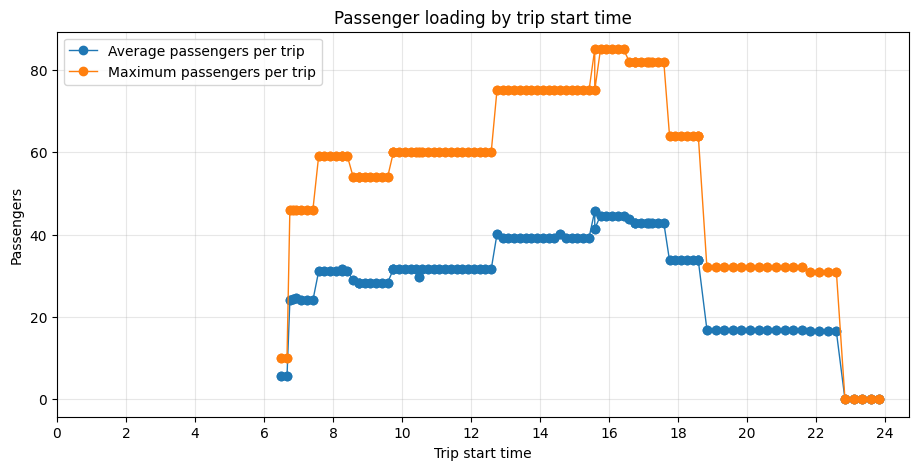

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    trip_summary["trip_start_decimal_hour"],
    trip_summary["avg_passengers"],
    marker="o",
    linewidth=1,
    label="Average passengers per trip"
)
ax.plot(
    trip_summary["trip_start_decimal_hour"],
    trip_summary["max_passengers"],
    marker="o",
    linewidth=1,
    label="Maximum passengers per trip"
)

ax.set_title("Passenger loading by trip start time")
ax.set_xlabel("Trip start time")
ax.set_ylabel("Passengers")
ax.set_xticks(range(0, 25, 2))
ax.grid(True, alpha=0.3)
ax.legend()

save_fig(fig, "passenger_loading_by_trip_start_time.png")
plt.show()

## 6. Passenger loading profile along selected trips

This compares representative trips across the day.

The notebook selects trips nearest to morning, midday, afternoon peak, and evening times.

In [9]:
def select_nearest_trip_ids(trip_summary, target_times):
    selected = []
    for label, target_hour in target_times.items():
        idx = (trip_summary["trip_start_decimal_hour"] - target_hour).abs().idxmin()
        row = trip_summary.loc[idx]
        selected.append({
            "label": label,
            "target_hour": target_hour,
            "trip_id": row["trip_id"],
            "trip_start_time": row["trip_start_time"]
        })
    return pd.DataFrame(selected).drop_duplicates("trip_id")

selected_trips = select_nearest_trip_ids(
    trip_summary,
    {
        "Early morning": 6.5,
        "Morning peak": 8.0,
        "Midday": 12.0,
        "Afternoon peak": 17.0,
        "Evening": 21.0,
    }
)

display(selected_trips)

,label,target_hour,trip_id,trip_start_time
0,Early morning,6.5,5695_40633,06:30:00
1,Morning peak,8.0,5695_40821,07:55:00
2,Midday,12.0,5695_41401,11:55:00
3,Afternoon peak,17.0,5695_42101,16:55:00
4,Evening,21.0,5695_42592,21:05:00


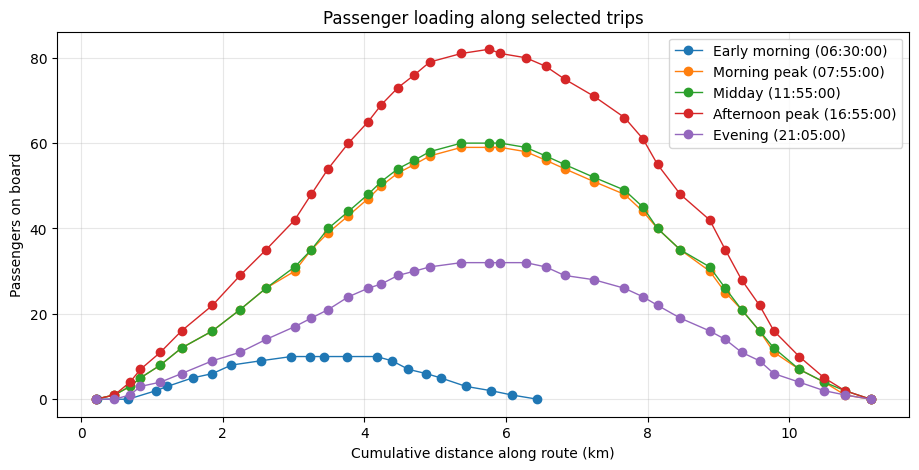

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

for _, selected in selected_trips.iterrows():
    trip_df = df[df["trip_id"] == selected["trip_id"]].sort_values("segment")
    label = f"{selected['label']} ({selected['trip_start_time']})"
    ax.plot(trip_df["cum_dist_km"], trip_df["passengers"], marker="o", linewidth=1, label=label)

ax.set_title("Passenger loading along selected trips")
ax.set_xlabel("Cumulative distance along route (km)")
ax.set_ylabel("Passengers on board")
ax.grid(True, alpha=0.3)
ax.legend()

save_fig(fig, "passenger_loading_along_selected_trips.png")
plt.show()

## 7. Passenger loading heatmap

Rows are trips ordered by start time.

Columns are stop-to-stop segment indices.

This plot is useful for seeing whether passenger loading changes mainly by time of day, by route position, or both.

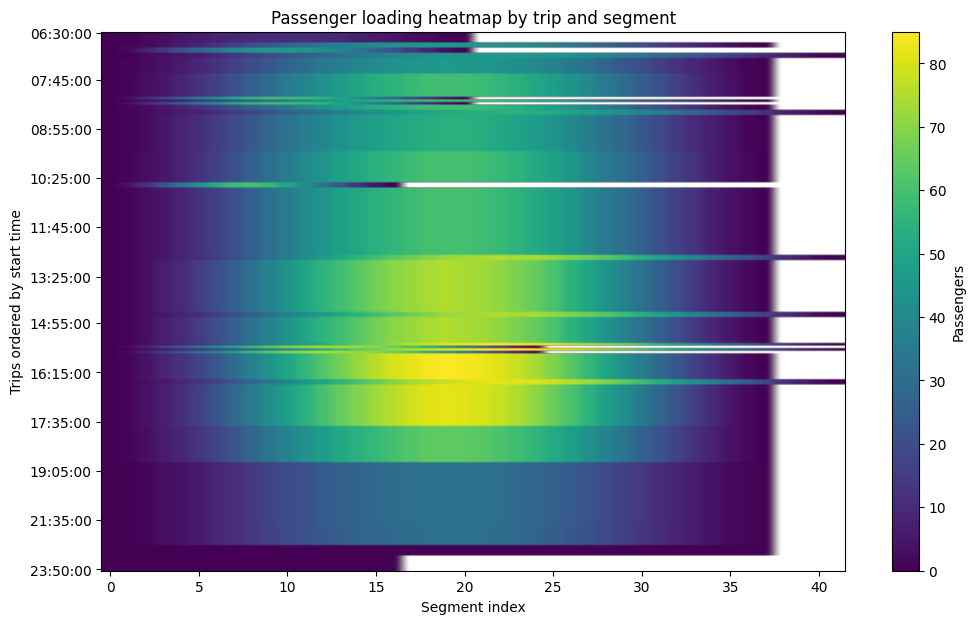

In [11]:
passenger_heatmap = (
    df.pivot_table(
        index=["trip_start_seconds", "trip_id", "trip_start_time"],
        columns="segment",
        values="passengers",
        aggfunc="mean"
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(passenger_heatmap.values, aspect="auto")
fig.colorbar(im, ax=ax, label="Passengers")

ax.set_title("Passenger loading heatmap by trip and segment")
ax.set_xlabel("Segment index")
ax.set_ylabel("Trips ordered by start time")

# Show a limited number of y-axis labels to keep the plot readable.
ytick_positions = np.linspace(0, len(passenger_heatmap.index) - 1, min(12, len(passenger_heatmap.index))).astype(int)
ytick_labels = [passenger_heatmap.index[i][2] for i in ytick_positions]
ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels)

save_fig(fig, "passenger_loading_heatmap_trip_segment.png")
plt.show()

## 8. Average energy consumption by stop-to-stop segment

This shows which route segments are more energy-intensive on average.

Large values may be caused by hills, high passenger load, short stop spacing, frequent acceleration, or low-speed operation.

In [12]:
segment_summary = (
    df.groupby("segment", as_index=False)
    .agg(
        avg_length_m=("length_m", "mean"),
        avg_grade_pct=("grade_%", "mean"),
        avg_passengers=("passengers", "mean"),
        avg_energy_kWh=("energy_kWh", "mean"),
        avg_kWh_per_km=("kWh_per_km", "mean"),
        min_kWh_per_km=("kWh_per_km", "min"),
        max_kWh_per_km=("kWh_per_km", "max"),
        trips_available=("trip_id", "nunique")
    )
)

display(segment_summary.head())

,segment,avg_length_m,avg_grade_pct,avg_passengers,avg_energy_kWh,avg_kWh_per_km,min_kWh_per_km,max_kWh_per_km,trips_available
0,0,203.334615,6.079712,0.000000,0.783663,3.864548,0.846,4.017,208
1,1,275.225000,3.899231,0.836538,0.749269,2.778962,0.792,2.909,208
2,2,227.437500,-4.790673,2.769231,0.010356,0.015115,-0.184,0.865,208
3,3,147.828846,-6.402981,5.490385,-0.053058,-0.366788,-0.594,1.900,208
4,4,286.410577,0.675865,8.317308,0.405135,1.420442,0.973,2.772,208


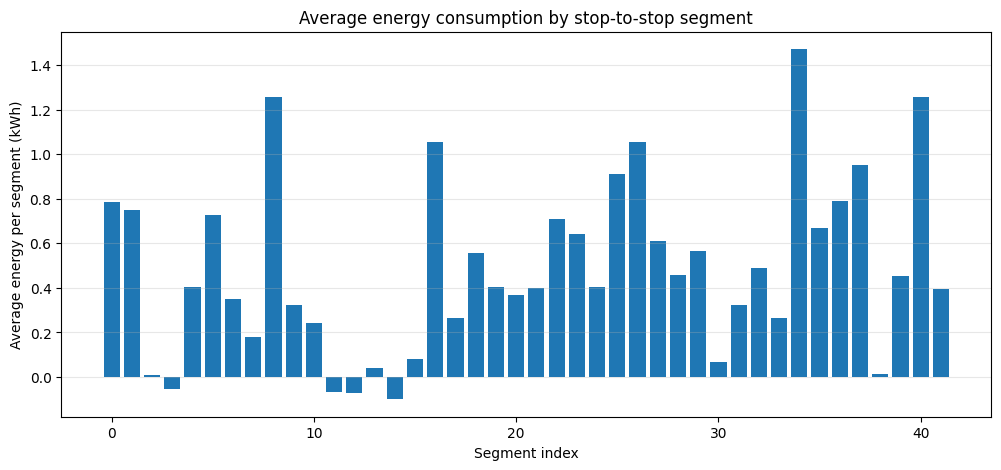

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(segment_summary["segment"], segment_summary["avg_energy_kWh"])
ax.set_title("Average energy consumption by stop-to-stop segment")
ax.set_xlabel("Segment index")
ax.set_ylabel("Average energy per segment (kWh)")
ax.grid(True, axis="y", alpha=0.3)

save_fig(fig, "average_energy_by_segment.png")
plt.show()

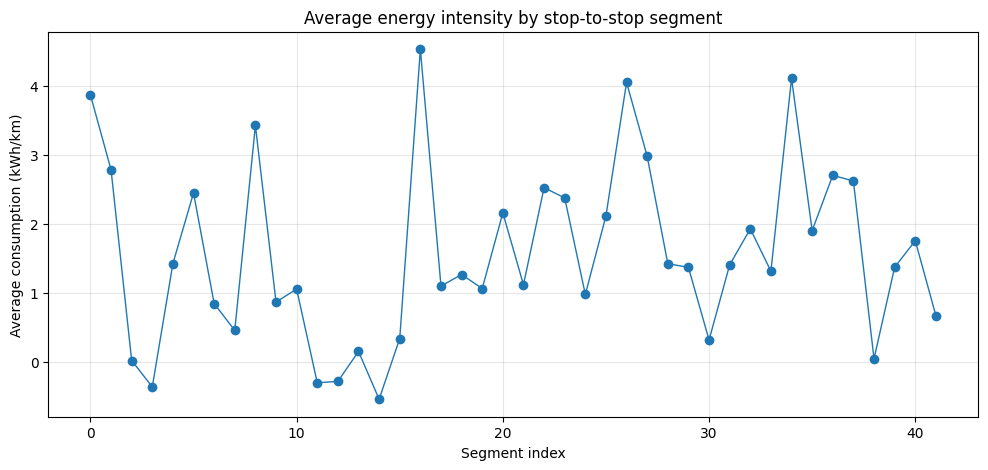

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(segment_summary["segment"], segment_summary["avg_kWh_per_km"], marker="o", linewidth=1)
ax.set_title("Average energy intensity by stop-to-stop segment")
ax.set_xlabel("Segment index")
ax.set_ylabel("Average consumption (kWh/km)")
ax.grid(True, alpha=0.3)

save_fig(fig, "average_kwh_per_km_by_segment.png")
plt.show()

## 9. Energy consumption by time of day

This checks whether trips at different times of day have different energy consumption.

This is important because passenger loading is time-dependent in your model.

In [15]:
hourly_trip_summary = (
    trip_summary.groupby("trip_start_hour", as_index=False)
    .agg(
        trips=("trip_id", "nunique"),
        avg_trip_energy_kWh=("total_energy_kWh", "mean"),
        avg_trip_kWh_per_km=("trip_kWh_per_km", "mean"),
        avg_passengers=("avg_passengers", "mean"),
        avg_soc_drop_pct=("soc_drop_pct", "mean")
    )
)

display(hourly_trip_summary)

,trip_start_hour,trips,avg_trip_energy_kWh,avg_trip_kWh_per_km,avg_passengers,avg_soc_drop_pct
0,6,10,15.300800,1.770015,16.829073,3.732000
1,7,12,16.667167,1.494545,27.526316,4.065000
2,8,16,16.818125,1.564141,29.834586,4.101250
3,9,14,18.244429,1.635978,29.729323,4.450000
4,10,14,16.449143,1.561256,31.319770,4.011429
5,11,12,18.371000,1.647328,31.578947,4.480000
6,12,12,18.670333,1.629484,34.253551,4.553333
7,13,12,18.699000,1.676740,39.157895,4.560000
8,14,12,18.595333,1.625322,39.306182,4.535000
9,15,14,17.935571,1.627217,41.968901,4.375714


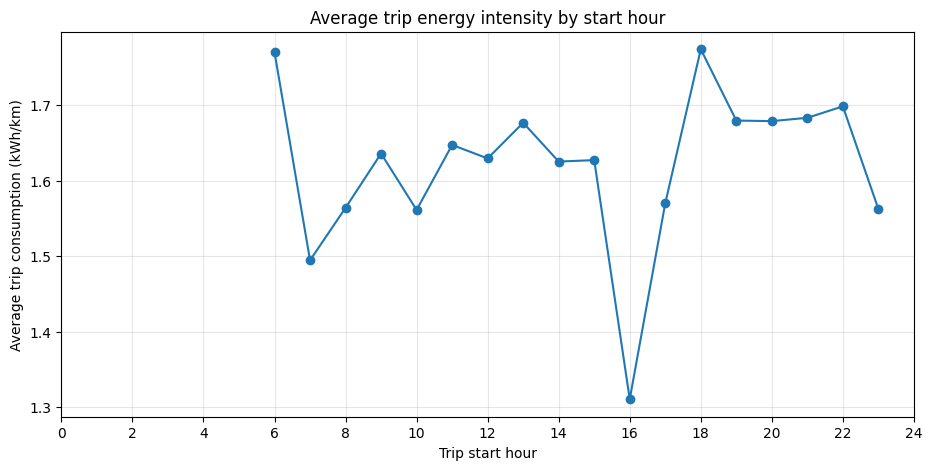

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(hourly_trip_summary["trip_start_hour"], hourly_trip_summary["avg_trip_kWh_per_km"], marker="o")
ax.set_title("Average trip energy intensity by start hour")
ax.set_xlabel("Trip start hour")
ax.set_ylabel("Average trip consumption (kWh/km)")
ax.set_xticks(range(0, 25, 2))
ax.grid(True, alpha=0.3)

save_fig(fig, "average_trip_kwh_per_km_by_start_hour.png")
plt.show()

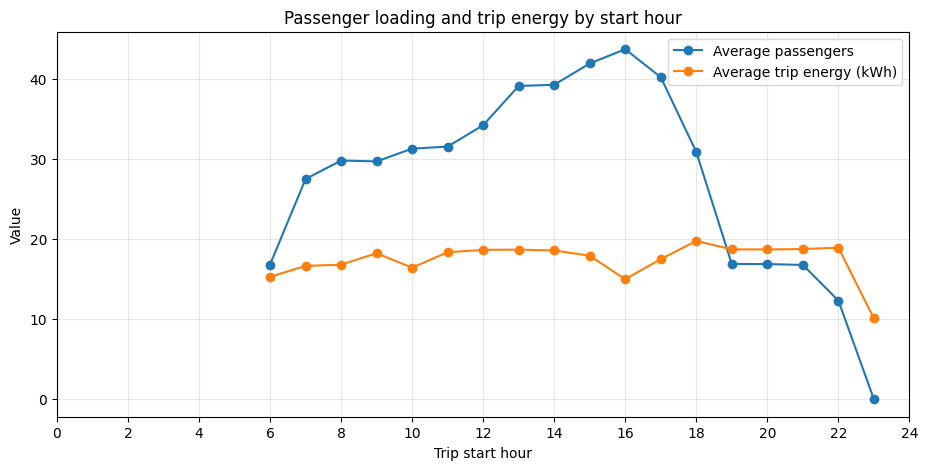

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(hourly_trip_summary["trip_start_hour"], hourly_trip_summary["avg_passengers"], marker="o", label="Average passengers")
ax.plot(hourly_trip_summary["trip_start_hour"], hourly_trip_summary["avg_trip_energy_kWh"], marker="o", label="Average trip energy (kWh)")

ax.set_title("Passenger loading and trip energy by start hour")
ax.set_xlabel("Trip start hour")
ax.set_ylabel("Value")
ax.set_xticks(range(0, 25, 2))
ax.grid(True, alpha=0.3)
ax.legend()

save_fig(fig, "passenger_and_energy_by_start_hour.png")
plt.show()

## 10. Energy heatmap by trip and segment

This reveals where high-energy segments occur across the day.

If a specific segment is always high, it is likely route/terrain related.

If the same segment becomes higher during peak periods, it may be passenger-load related.

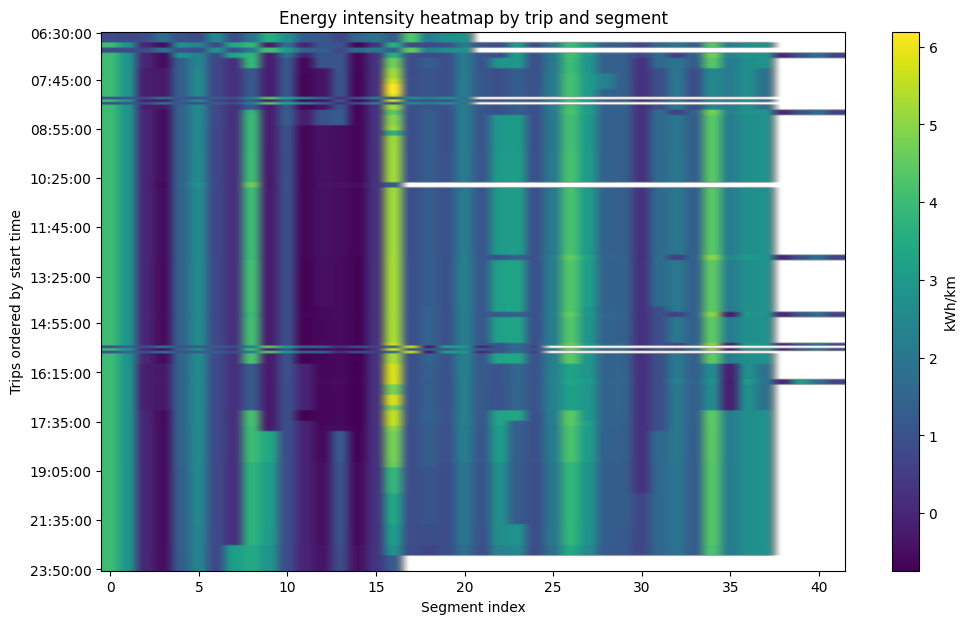

In [18]:
energy_heatmap = (
    df.pivot_table(
        index=["trip_start_seconds", "trip_id", "trip_start_time"],
        columns="segment",
        values="kWh_per_km",
        aggfunc="mean"
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(energy_heatmap.values, aspect="auto")
fig.colorbar(im, ax=ax, label="kWh/km")

ax.set_title("Energy intensity heatmap by trip and segment")
ax.set_xlabel("Segment index")
ax.set_ylabel("Trips ordered by start time")

ytick_positions = np.linspace(0, len(energy_heatmap.index) - 1, min(12, len(energy_heatmap.index))).astype(int)
ytick_labels = [energy_heatmap.index[i][2] for i in ytick_positions]
ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels)

save_fig(fig, "energy_intensity_heatmap_trip_segment.png")
plt.show()

## 11. SoC drop by trip start time

At the moment, each trip is simulated independently.

So this plot shows **per-trip SoC drop**, not a full-day vehicle duty cycle.

Later, when trips are chained by vehicle/block, this can become a full-day SoC trace.

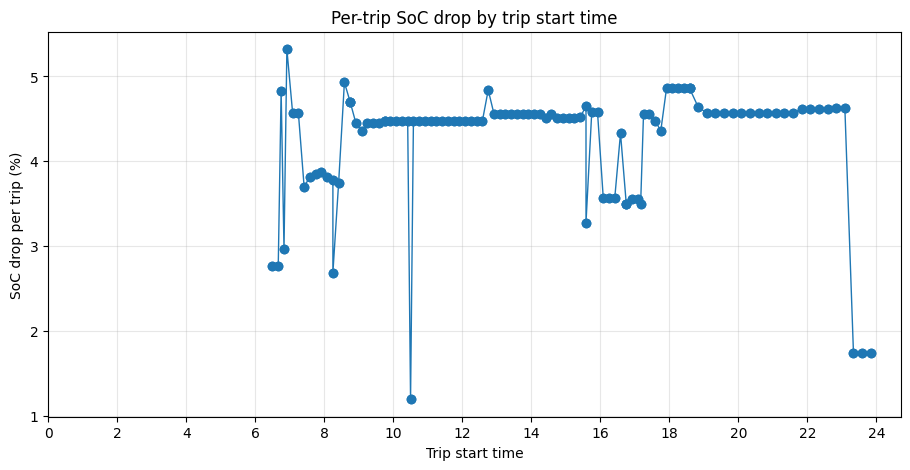

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(trip_summary["trip_start_decimal_hour"], trip_summary["soc_drop_pct"], marker="o", linewidth=1)
ax.set_title("Per-trip SoC drop by trip start time")
ax.set_xlabel("Trip start time")
ax.set_ylabel("SoC drop per trip (%)")
ax.set_xticks(range(0, 25, 2))
ax.grid(True, alpha=0.3)

save_fig(fig, "soc_drop_by_trip_start_time.png")
plt.show()

## 12. Relationship checks

These plots help check whether the model behaves sensibly.

Expected behaviour:

- More passengers should usually increase energy consumption, but the relationship may be weak if route grade dominates.
- Uphill grades should generally increase `kWh_per_km`.
- Negative or very low energy values can occur on downhill segments because of regenerative braking.

Correlation between average passengers and trip kWh/km: -0.287


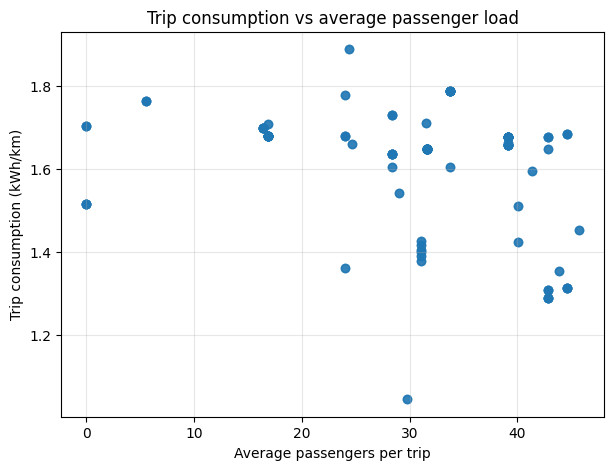

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(trip_summary["avg_passengers"], trip_summary["trip_kWh_per_km"], alpha=0.7)
ax.set_title("Trip consumption vs average passenger load")
ax.set_xlabel("Average passengers per trip")
ax.set_ylabel("Trip consumption (kWh/km)")
ax.grid(True, alpha=0.3)

corr = trip_summary[["avg_passengers", "trip_kWh_per_km"]].corr().iloc[0, 1]
print(f"Correlation between average passengers and trip kWh/km: {corr:.3f}")

save_fig(fig, "trip_consumption_vs_passenger_load.png")
plt.show()

Correlation between segment grade and segment kWh/km: 0.771


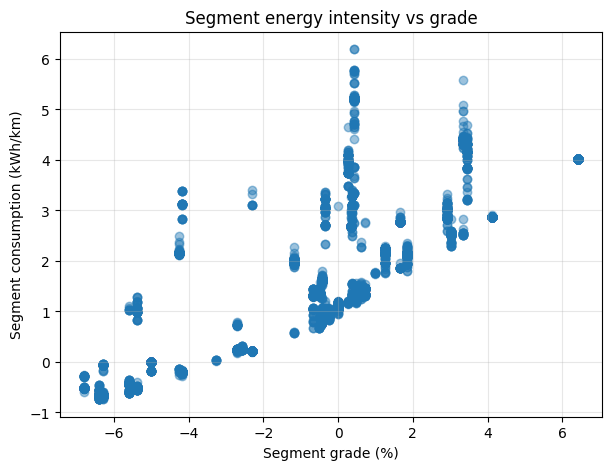

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df["grade_%"], df["kWh_per_km"], alpha=0.25)
ax.set_title("Segment energy intensity vs grade")
ax.set_xlabel("Segment grade (%)")
ax.set_ylabel("Segment consumption (kWh/km)")
ax.grid(True, alpha=0.3)

corr = df[["grade_%", "kWh_per_km"]].corr().iloc[0, 1]
print(f"Correlation between segment grade and segment kWh/km: {corr:.3f}")

save_fig(fig, "segment_consumption_vs_grade.png")
plt.show()

## 13. Result distributions

These distribution plots are useful for detecting outliers.

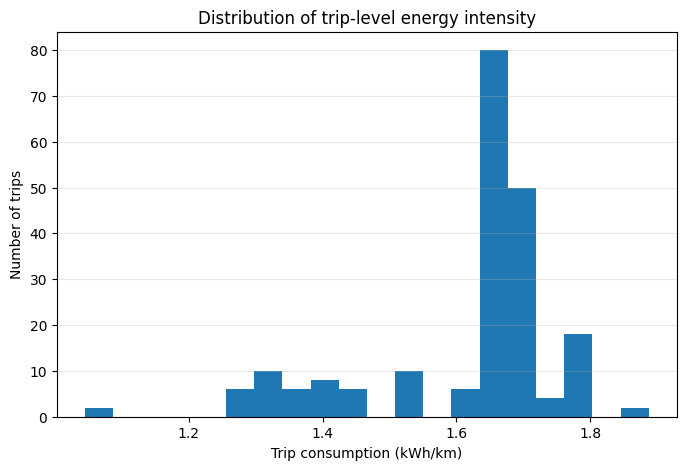

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(trip_summary["trip_kWh_per_km"], bins=20)
ax.set_title("Distribution of trip-level energy intensity")
ax.set_xlabel("Trip consumption (kWh/km)")
ax.set_ylabel("Number of trips")
ax.grid(True, axis="y", alpha=0.3)

save_fig(fig, "trip_kwh_per_km_distribution.png")
plt.show()

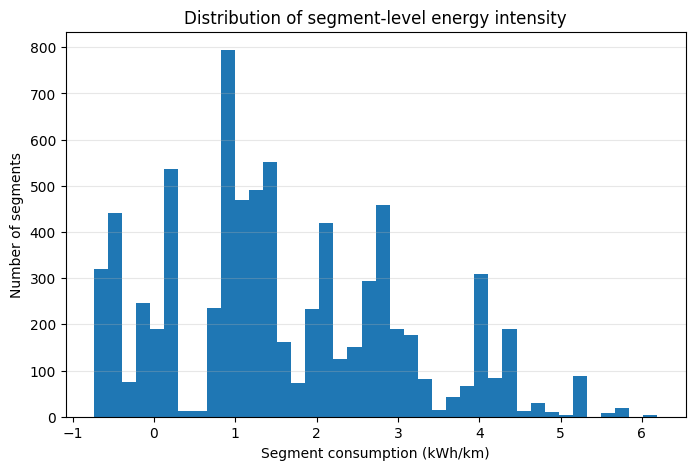

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df["kWh_per_km"], bins=40)
ax.set_title("Distribution of segment-level energy intensity")
ax.set_xlabel("Segment consumption (kWh/km)")
ax.set_ylabel("Number of segments")
ax.grid(True, axis="y", alpha=0.3)

save_fig(fig, "segment_kwh_per_km_distribution.png")
plt.show()

## 14. Daily service energy profile

This plot estimates how much route energy demand is associated with trips starting in each hour.

It is useful for charging-infrastructure planning because it gives a first view of when energy demand is generated during the day.

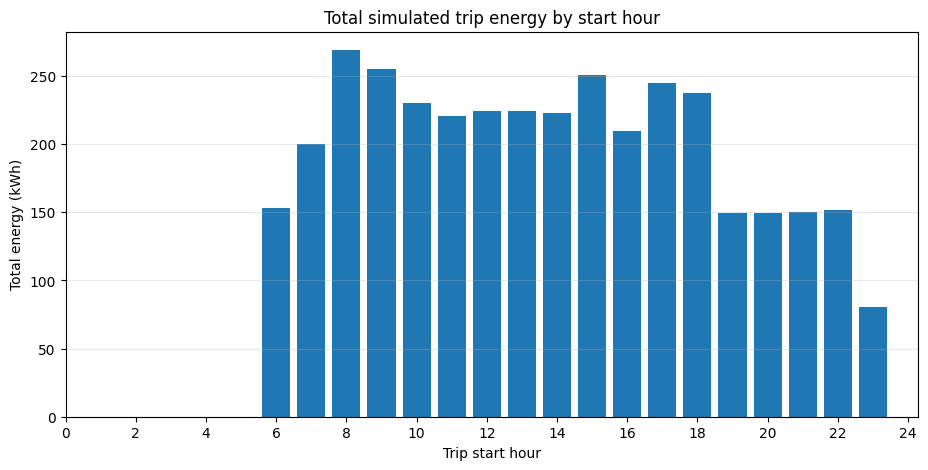

,trip_start_hour,trips,total_energy_kWh,total_distance_km
0,6,10,153.008,87.236
1,7,12,200.006,133.824
2,8,16,269.090,172.976
3,9,14,255.422,156.128
4,10,14,230.288,143.238
5,11,12,220.452,133.824
6,12,12,224.044,137.782
7,13,12,224.388,133.824
8,14,12,223.144,137.782
9,15,14,251.098,154.628


In [24]:
hourly_total_energy = (
    trip_summary.groupby("trip_start_hour", as_index=False)
    .agg(
        trips=("trip_id", "nunique"),
        total_energy_kWh=("total_energy_kWh", "sum"),
        total_distance_km=("total_distance_km", "sum")
    )
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(hourly_total_energy["trip_start_hour"], hourly_total_energy["total_energy_kWh"])
ax.set_title("Total simulated trip energy by start hour")
ax.set_xlabel("Trip start hour")
ax.set_ylabel("Total energy (kWh)")
ax.set_xticks(range(0, 25, 2))
ax.grid(True, axis="y", alpha=0.3)

save_fig(fig, "total_energy_by_start_hour.png")
plt.show()

display(hourly_total_energy)

## 15. Export summary tables

These tables are useful for reporting and later model validation.

In [25]:
SUMMARY_DIR = Path("../data/processed/visualisation_summary")
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

trip_summary.to_csv(SUMMARY_DIR / "trip_level_summary.csv", index=False)
segment_summary.to_csv(SUMMARY_DIR / "segment_level_summary.csv", index=False)
hourly_trip_summary.to_csv(SUMMARY_DIR / "hourly_trip_summary.csv", index=False)
hourly_total_energy.to_csv(SUMMARY_DIR / "hourly_total_energy_summary.csv", index=False)

print("Saved summary tables to:", SUMMARY_DIR)

Saved summary tables to: ..\data\processed\visualisation_summary


## 16. How to interpret the results

Use this checklist when reviewing the figures:

1. **Passenger loading by trip start time**  
   Check whether morning and afternoon trips have higher loads. If not, the hourly loading profile may be too flat.

2. **Passenger loading along selected trips**  
   Check whether passengers accumulate and alight smoothly. If every trip has the same pattern, the loading model may be too simple.

3. **Average energy by segment**  
   Identify consistently energy-intensive stop-to-stop links. These are important for route-level energy modelling.

4. **Energy by start hour**  
   Check whether higher passenger loads cause higher consumption at peak times.

5. **SoC drop by trip**  
   This is currently per-trip only. It does not yet represent a full vehicle duty cycle.

6. **Outliers**  
   Very high `kWh_per_km` may come from short segments, steep grades, or frequent acceleration. Negative values can occur on downhill regenerative-braking segments.